In [1]:
#general imports
from pathlib import Path
import pandas as pd
import numpy as np
from typing import List

#rdkit imports
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

#sklearn/scipy imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import gaussian_kde

#plotting imports (mpl)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

"""
### 'RF_Regressor_6-Mem_Hetarynes.ipynb' - @GCH v1.0 - last updt. 05/11/26

### Notebook Overview:
This notebook contains python code to build a baseline Random Forest (RF) Regression ML model for 6-membered
Hetarynes. The model is trained on Morgan Fingerprints of Aryne SMILES strings to predict DFT-calculated
Dehydrogenation Energies (The energy of the reaction: Arene ==> Aryne + H2). The motivation of this approach
is to establish how well a failry "naiive" ML model, trained using only SMILES and DFT-calculated energies, 
can predict the energy of dehydrogenation for unseen arynes. 

### Motivation:
An all-in-one Jupyter Notebook for building a Random Forest Regression model for predicting dehydrogenation
energies - specifically for 6-Membered Hetarynes. 

### Details on Morgan Fingerprints:
Morgan Fingerprints are obtained from SMILES strings by:
1. Converting SMILES strings to RDKit Mol objects
2. Employing RDKit's rdFingerprintGenerator method to obtain a binary ExplicitBitVect (bit vector) for the SMILES
3. Converting fingerprint bit vectors to numpy arrays

### How to use this Notebook:
1. Define the relevant paths and directories, below.
2. Run all cells in the notebook.
3. Local directory will contain .png files for the generated scatterplots.

"""

In [2]:
"""
Define Paths and Relevant Directories in this cell. 
"""

#path containing the current script (Module8/RF dir)
rf_regress_dir = Path.cwd()

#the project TLD is several "parents" above current dir
project_tld = rf_regress_dir.parents[2]

#dir containing the .csv with extracted parameters, "Aryne_Calculated_Molecular_Descriptors.csv"
mod7_dir = project_tld / "Module7_Extract_DFT_Molecular_Descriptors" 

In [3]:
def validate_dataframe_format(df: pd.DataFrame, required_cols: List[str]) -> bool:
    """
    Function: Validate DataFrame has required columns and basic structure for data import

    Inputs: 
        - df: pd.DataFrame; a Pandas DataFrame to parse for required_cols
        - required_cols: List[str]; a list of column headers required for some task

    Returns:
        - Bool; True = df is OK; False = df not correct
    """

    #check that the passed info is indeed a pd.DF
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")

    #check the passed df for column headers passed as a list
    missing_cols = [col for col in required_cols if col not in df.columns]

    #if some cols are missing, report to user
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    #if df is completely empty, report to user
    if df.empty:
        raise ValueError("DataFrame is empty")

    #return True if everything OK
    return True

In [4]:
def smiles_to_morgan_fingerprint(smiles_list: List[str], radius: int = 2, nBits: int = 2048) -> np.array:
    """
    Function: Convert SMILES strings to Morgan fingerprints (ECFPs)
    
    Input:
        - smiles_list: List[str]: list of SMILES strings
        - radius: int = 2: fingerprint radius (default=2)
        - nBits: int = 2048: number of bits in fingerprint (default=2048)
        - useChirality: bool = False; whether to use chirality information
        - useBondTypes: bool = True; whether to use bond type information
    
    Returns:
        - np.array(fingerprints): numpy array of fingerprints
    """

    #init a list to store fingerprints
    fingerprints = []
    
    #loop over all the incoming SMILES str
    for smiles in smiles_list:
        
        # Convert SMILES to molecule object
        mol = Chem.MolFromSmiles(smiles)

        #if the mol is valid,
        if mol is not None:

            #Initialize MorganGenerator according to our dimensions
            fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
            
            #Generate the Morgan fingerprint for our mol
            fp = fpgen.GetFingerprint(mol)

            #Init an empty array of zeroes same size as our FP array
            fp_array = np.zeros((nBits,), dtype=np.uint8)

            #populate our empty array with calculated fp data
            DataStructs.ConvertToNumpyArray(fp, fp_array)

            #append the array to fingerprints
            fingerprints.append(fp_array)
            

            # #calculate the FP using RDKit
            # fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius, nBits)

            # #populate our empty array with calculated data
            # rdkit.DataStructs.ConvertToNumpyArray(fp, fp_array)

            # #append the array to fingerprints
            # fingerprints.append(fp_array)
            
            # # Generate a Morgan fingerprint
            # fp = rdMolDescriptors.GetMorganFingerprint(mol, radius, nBits=nBits,
            #                                            useChirality=useChirality,
            #                                            useBondTypes=useBondTypes)

        #smiles/mol was invalid
        else:
            # If SMILES is invalid, create zero vector
            print(f"Warning: Could not process SMILES: {Chem.MolToSmiles(mol)}")

            #append a NaN, essentially
            fingerprints.append(np.zeros(nBits))

    #return the fingerprints 
    return np.array(fingerprints)

In [5]:
"""
Import descriptors from "6_membered_Calculated_Molecular_Descriptors.csv" located in Module7 directory.
Checks the imported DF for data/expected column headers. 
"""

#The Module7 directory contains the .csv we need in this notebook
input_csv_dir = mod7_dir / "6_membered_Calculated_Molecular_Descriptors.csv"

#Read in the specified .csv as a pd DataFrame
incoming_data = pd.read_csv(input_csv_dir)

#list containing the required cols
required_cols = ["aryne_ID", "aryne_smiles",
                "dehydrogenation_energy"]

#check that the passed DF is valid for our purposes (has correct cols and data)
validated_df = validate_dataframe_format(incoming_data, required_cols)

#if the DF is ok, proceed and give some info
if validated_df:
    print(f"Found {len(incoming_data)} SMILES strings in target csv file: '{input_csv_dir.name}'\n")

#otherwise, fix the df
else:
    print(f"Passed DataFrame could not be parsed for SMILES or does not contain correct col. headers.\n")

#print some of the df
incoming_data.head()

Found 6648 SMILES strings in target csv file: '6_membered_Calculated_Molecular_Descriptors.csv'



,arene_ID,arene_smiles,arene_energy,aryne_ID,aryne_smiles,aryne_energy,dehydrogenation_energy,Sz_Aryne_Ring,RingSys_Type,Aryne_Aindx_1,...,Max_angle_dev,Sum_abs_dev,Aryne_DiH_Ang,eHOMO(eV),eLUMO(eV),H_L_Gap(eV),Hirsh_chgs_Aindx_1,Hirsh_chgs_Aindx_2,Sum_Abs_Hirsh_aryne,Abs_Dif_Bnd_Angl
0,arene_2,c1csn2nn[nH]cc-2o1,-846.4294,aryne_2,c1oc2c[nH]nnn-2sc#1,-845.1003,103.7738,6,multi,9,...,28.1870,32.3229,9.361,-7.5885,-1.8409,5.7476,-0.1534,0.0712,0.2246,32.3229
1,arene_3,O=c1cnc2occsc=2c1=O,-946.3140,aryne_3,O=c1cnc2oc#csc=2c1=O,-944.9744,110.3626,6,multi,6,...,27.9700,28.5260,0.049,-7.6077,-3.6957,3.9120,0.0756,-0.1217,0.1973,27.4140
2,arene_4,O=c1cnc2sc(=O)ccc2s1,-1269.2819,aryne_4,O=c1c#cc2sc(=O)cnc2s1,-1267.9693,93.4199,6,multi,2,...,16.0394,29.2699,0.582,-8.2904,-2.7467,5.5437,-0.0285,-0.0286,0.0571,2.8089
3,arene_5,O=c1ccn2sccsn2[nH]1,-1228.5052,aryne_5,O=c1c#cn2sccsn2[nH]1,-1227.1702,107.4761,6,multi,2,...,11.5546,15.8775,28.895,-7.5024,-1.8204,5.6820,-0.1116,0.0126,0.1242,15.8775
4,arene_7,O=c1ncn2cnccn2c1=O,-599.7472,aryne_8,O=c1ncn2cnc#cn2c1=O,-598.3859,123.9795,6,multi,7,...,22.9304,28.4099,0.193,-7.9336,-2.5449,5.3887,0.0734,-0.0427,0.1161,28.4099


In [6]:
"""
This cell is used to import relevant data and apply an 80:20 train/test split on the imported data.
Aryne SMILES and dehydrogenation energies are read from 'Aryne_Calculated_Molecular_Descriptors.csv'
Simple Random Sampling (SRS) is used to apply the 80/20 split. 
"""

print(f"Importing aryne SMILES and Dehydrogenation Energies...")

#Retain the column of aryne SMILES as a list
aryne_smiles = incoming_data['aryne_smiles'].tolist()
print(f"\tNumber of aryne SMILES to be fingerprinted: \t{len(aryne_smiles)}")

#Retain the column of dehydrogenation energies as a list
dehyd_energies = incoming_data['dehydrogenation_energy'].tolist()
print(f"\tNumber of matching dehydration energies: \t{len(dehyd_energies)}")

#Apply a Train/Test Split; we will start with 80:20 and see how it performs
# X = SMILEs data => Morgan Fingerprints (ECFPs; see: J. Chem. Inf. Model., Vol. 50, No. 5, 2010)
# Y = DFT-calculated dehydration energies (Arene ==> Aryne + H2) 
print(f"\nApplying an 80:20 Train/Test split...")
X_train, X_test, y_train, y_test = train_test_split(aryne_smiles, dehyd_energies, test_size=0.2, random_state=40)

num_train = len(X_train)
num_test = len(X_test)
print(f'\tNumber of arynes in training set: \t\t{num_train}')
print(f'\tNumber of arynes in test set: \t\t\t{num_test}')

Importing aryne SMILES and Dehydrogenation Energies...
	Number of aryne SMILES to be fingerprinted: 	6648
	Number of matching dehydration energies: 	6648

Applying an 80:20 Train/Test split...
	Number of arynes in training set: 		5318
	Number of arynes in test set: 			1330


In [7]:
"""
This cell is used to calculate Morgan Fingerprints from SMILES strings using RDKIt.
"""

#Print a header
print(f"Converting {len(aryne_smiles)} SMILES to Morgan Fingerprints...")

# Convert SMILES to fingerprints for training and test sets
X_train_fp = smiles_to_morgan_fingerprint(X_train)
X_test_fp = smiles_to_morgan_fingerprint(X_test)

#print a summary of the two sets of Morgan FPs
print(f"\nFinished:\n\tTraining fingerprints shape: {X_train_fp.shape}\n\tTest fingerprints shape: {X_test_fp.shape}")

Converting 6648 SMILES to Morgan Fingerprints...

Finished:
	Training fingerprints shape: (5318, 2048)
	Test fingerprints shape: (1330, 2048)


In [8]:
"""
Train a Random Forest Regression model to evalute baseline model performance. 

We are asking our model to "learn" the relation between Morgan Fingerprints and our DFT-calculated
Dehydrogenation energy. Then we will evaluate how well our model has mapped this relationship by
evaluating its statistical performance over the training set. If it is good, we will make predictions
for our held-out test set of arynes (Given this Morgan FP, what is its dehydrogenation energy?)

Notably, n_estimators=500; default in sklearn = 100 => there are 500 trees in the forest.
"""

#Create Random Forest Regressor model
rf_baseline = RandomForestRegressor(
    n_estimators=500,  #500 trees
    n_jobs=16,         #Use multiple cores for faster training
    random_state=42    #Apply a set seed for reproducible results
)

# Train the Random Forest model using calculated Morgan Fingerprints and dehydrogenation energys
print(f"Training Random Forest model...\n\tX Data: Morgan Fingerprints\n\tY Data: Dehydrogenation Energy")
rf_baseline.fit(X_train_fp, y_train)

Training Random Forest model...
	X Data: Morgan Fingerprints
	Y Data: Dehydrogenation Energy


,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
"""
Evaluate RF Regression model performance on the training data set. We ask our fitted model to forget that
it "knows" the dehydrogenation energy for every Fingerprint in our training set. Then we ask it to make a
prediction for the dehydrogenation energy using only the fingerprint data in the training set. In other
words, forget Y, use X to predict Y. 
"""

#Ask the RF Model to make a prediction for the training dehydrogenation energy
#using the training FP data
y_train_pred = rf_baseline.predict(X_train_fp)

#calculate the training set MAE
train_mae = mean_absolute_error(y_train, y_train_pred)
print(f'Training Set Mean Absolute Error (MAE): {round(train_mae, 2)} kcal/mol')

#calculate the training set R^2 
train_r2 = r2_score(y_train, y_train_pred)
print(f'Training Set R^2: {round(train_r2, 2)}')

Training Set Mean Absolute Error (MAE): 0.49 kcal/mol
Training Set R^2: 0.99


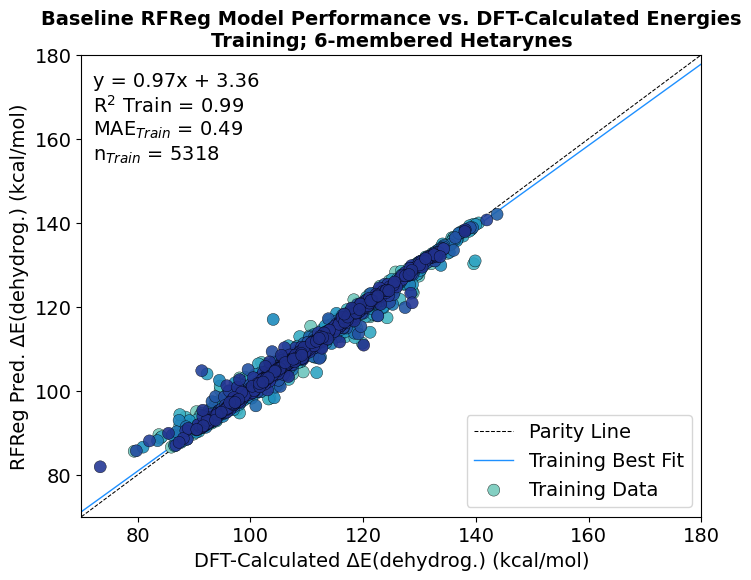

In [10]:
"""
This cell will render and save a parity plot (an XY scatterplot) of the DFT-calculated Dehydrogenation Energy
vs. the RF-Regressor Model's best-guess prediction for the Dehydrogenation Energy using Morgan FPs from SMILES
over the TRAINING DATA.

We are looking for 1:1 parity, ideally, or X=Y. Other criteria are the Mean Absolute Error (MAE, for a given 
SMILES, how much error, on average, do we expect our prediction to have?) and the R^2 (1 is ideal, >0.9 shows 
a very strong correlation). 
"""

### Parity Plot of Training Data: Baseline RF predictions vs. DFT-calculated Values ### 
#How Well does the Baseline RF model perform relative to DFT-calculatd values?
#Compare the ability of Baseline RF to predict dE(dehyd.) using only SMILES; Parity Plot

#parity plot is just a scatter plot; feed it training_y and predicted_y (training)
fig, ax = plt.subplots(figsize=(8, 6))

#add a parity line (can omit if you want)
ax.axline((60, 60), (180, 180), lw=0.75, color='black', linestyle='--', label='Parity Line', zorder=0)

#caclulate point density
train_dft_array = np.array(y_train)
train_pred_array = np.array(y_train_pred)

xy = np.stack([train_dft_array, train_pred_array])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
train_dft_array, train_pred_array, xy_density = train_dft_array[idx],train_pred_array[idx], xy_density[idx]

#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

plt.scatter(y_train, y_train_pred, c=xy_density, cmap=my_blu, linewidths=0.30, edgecolors='black', alpha=0.9, s=75, label='Training Data')

#Add a best fit line for the training data
x = y_train
y = y_train_pred
#calc the line
m, b = np.polyfit(x, y, 1)
#add line to the plot
ax.axline((0, b), slope=m, lw=1, color='dodgerblue', linestyle='-', label='Training Best Fit', zorder=0)

#add some model stats/diagnostics in the upper-left of the plot
#Format a line equation using training data
line_eq = f'y = {round(m, 2)}x + {round(b, 2)}'

#calculate R^2 for training set
training_rsq = round(r2_score(y_train, y_train_pred), 2)

#formatting labels for the stats section
rsq_label = 'R$^{2}$ Train'
mae_train_label = 'MAE$_{Train}$'
n_train_label = 'n$_{Train}$'

#add labels as needed
training_perf_details = f'{line_eq}\n{rsq_label} = {training_rsq}\n{mae_train_label} = {round(train_mae, 2)}\n{n_train_label} = {num_train}'
#position the text on the plot (x,y)
ax.text(72, 176, training_perf_details, fontsize=14, verticalalignment='top', horizontalalignment='left')

#axes/plot labels and size
plt.title("Baseline RFReg Model Performance vs. DFT-Calculated Energies\nTraining; 6-membered Hetarynes", fontsize=14, fontweight='bold')
plt.xlabel("DFT-Calculated ΔE(dehydrog.) (kcal/mol)", fontsize=14) 
plt.ylabel("RFReg Pred. ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)

#plot range
plt.xlim(70,180)
plt.ylim(70,180)

#set up the legend
ax.legend()
handles, labels = ax.get_legend_handles_labels()
reordered_handles = [handles[i] for i in [0, 2, 1]]
reordered_labels = [labels[i] for i in [0, 2, 1]]
ax.legend(reordered_handles, reordered_labels, fontsize=14)

#save a copy of the figure
plt.savefig('Baseline_RF_Training_Calc_vs_Pred_6-membered_training.png', dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [11]:
"""
Next we will evaluate our RF Regression model's performance on the held out test set of SMILES. We ask our
our fitted model to use Morgan Fingerprints and its "learned" knowledge of how FPs map to energies to make 
predictions for the dehydrogenation energies of molecules it has not yet seen or learned about. 
"""

#Ask the RF Model to make a prediction for the training dehydrogenation energy
#using the training FP data
y_test_pred = rf_baseline.predict(X_test_fp)

#calculate the training set MAE
test_mae = mean_absolute_error(y_test, y_test_pred)
print(f'Test Set Mean Absolute Error (MAE): {round(test_mae, 2)} kcal/mol')

#calculate the training set R^2 
test_r2 = r2_score(y_test, y_test_pred)
print(f'Test Set R^2: {round(test_r2, 2)}')

Test Set Mean Absolute Error (MAE): 1.32 kcal/mol
Test Set R^2: 0.93


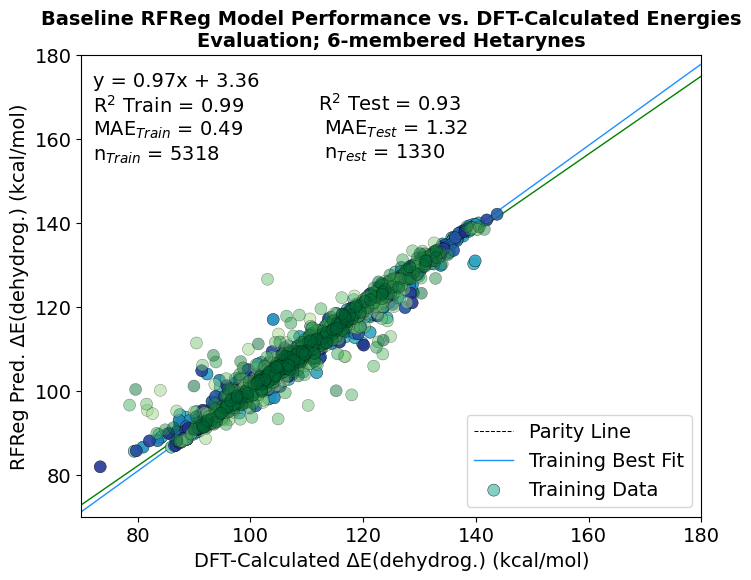

In [13]:
"""
This cell renders and saves a parity plot (an XY scatterplot) of the DFT-calculated Dehydrogenation Energy
vs. the RF-Regressor Model's best-guess prediction for the Dehydrogenation Energy using Morgan FPs from SMILES
for the TEST DATA. We ask our model to make actual predictions on unseen molecules (gold dots in the plots).

We are looking for 1:1 parity, ideally, or X=Y. Other criteria are the Mean Absolute Error (MAE, for a given 
SMILES, how much error, on average, do we expect our prediction to have?) and the R^2 (1 is ideal, >0.9 shows 
a very strong correlation). 
"""
 
#How well does the Baseline RF Regression model predict energies of dehydrogenation?

#parity plot is just a scatter plot; feed it training_y and predicted_y (training)
fig, ax = plt.subplots(figsize=(8, 6))

#add a parity line (can omit if you want)
#ax.axline((60, 60), (180, 180), lw=0.75, color='black', linestyle='--', label='Parity Line', zorder=0)

#caclulate point density
train_dft_array = np.array(y_train)
train_pred_array = np.array(y_train_pred)

xy = np.stack([train_dft_array, train_pred_array])
xy_density = gaussian_kde(xy)(xy)

#sort so most-dense points plotted last
idx = xy_density.argsort()
train_dft_array, train_pred_array, xy_density = train_dft_array[idx],train_pred_array[idx], xy_density[idx]

#6mem_colormap
my_blu = plt.cm.YlGnBu(np.linspace(0.35,0.9,100))
my_blu = ListedColormap(my_blu[8:,:-1])

plt.scatter(y_train, y_train_pred, c=xy_density, cmap=my_blu, linewidths=0.30, edgecolors='black', alpha=0.9, s=75, label='Training Data')

#Add a best fit line for the training data
x = y_train
y = y_train_pred
#calc the line
m, b = np.polyfit(x, y, 1)
#add line to the plot
ax.axline((0, b), slope=m, lw=1, color='dodgerblue', linestyle='-', label='Training Best Fit', zorder=0)

#add some model stats/diagnostics in the upper-left of the plot
#Format a line equation using training data
line_eq = f'y = {round(m, 2)}x + {round(b, 2)}'

#calculate R^2 for training set
training_rsq = round(r2_score(y_train, y_train_pred), 2)

#formatting labels for the stats section
rsq_label = 'R$^{2}$ Train'
mae_train_label = 'MAE$_{Train}$'
n_train_label = 'n$_{Train}$'

#add labels as needed
training_perf_details = f'{line_eq}\n{rsq_label} = {training_rsq}\n{mae_train_label} = {round(train_mae, 2)}\n{n_train_label} = {num_train}'
#position the text on the plot (x,y)
ax.text(72, 176, training_perf_details, fontsize=14, verticalalignment='top', horizontalalignment='left')

### Here we add our Test Set data to the plot ###
#caclulate point density for test data
test_dft_array = np.array(y_test)
test_pred_array = np.array(y_test_pred)
xy2 = np.stack([test_dft_array, test_pred_array])
xy2_density = gaussian_kde(xy2)(xy2)
#sort so most-dense points plotted last
idx2 = xy2_density.argsort()
test_dft_array, test_pred_array, xy2_density = test_dft_array[idx2],test_pred_array[idx2], xy2_density[idx2]

#Test set colors
my_gradient = plt.cm.YlGn(np.linspace(0.35,0.9,100))
my_gradient = ListedColormap(my_gradient[8:,:-1])

#add test set points to the plot
plt.scatter(y_test, y_test_pred, c=xy2_density, cmap=my_gradient, linewidths=0.30, edgecolors='black', alpha=0.5, s=75, label='Test Data')
rsq_test_label = 'R$^{2}$ Test'
mae_test_label = 'MAE$_{Test}$'
n_test_label = 'n$_{Test}$'
training_perf_details = f'{rsq_test_label} = {round(test_r2,2)}\n {mae_test_label} = {round(test_mae, 2)}\n {n_test_label} = {num_test}'
ax.text(112, 171, training_perf_details, fontsize=14, verticalalignment='top', horizontalalignment='left')

#add test set best fit line to the plot
# ax.axline((0, test_b), slope=test_m, lw=1, color='green', linestyle='-', label='Test Best Fit', zorder=0)

#axes/plot labels and size
plt.title("Baseline RFReg Model Performance vs. DFT-Calculated Energies\nEvaluation; 6-membered Hetarynes", fontsize=14, fontweight='bold')
plt.xlabel("DFT-Calculated ΔE(dehydrog.) (kcal/mol)", fontsize=14) 
plt.ylabel("RFReg Pred. ΔE(dehydrog.) (kcal/mol)", fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)

#calc best fit line for the test (can omit)
test_m, test_b  = np.polyfit(y_test, y_test_pred, 1)
#Format a line equation using test data
line_eq = f'y = {round(test_m, 2)}x + {round(test_b, 2)}'

#add test set best fit line to the plot
ax.axline((0, test_b), slope=test_m, lw=1, color='green', linestyle='-', label='Test Best Fit', zorder=0)

#plot range
plt.xlim(70,180)
plt.ylim(70,180)

#set up the legend
ax.legend(fontsize=14)
# handles, labels = ax.get_legend_handles_labels()
# print(labels)
# reordered_handles = [handles[i] for i in [0, 2, 1]]
# reordered_labels = [labels[i] for i in [0, 2, 1]]
ax.legend(reordered_handles, reordered_labels, fontsize=14)

#save a copy of the figure
plt.savefig('Baseline_RF_Training_Calc_vs_Pred_6-membered_evaluation.png', dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [34]:
### Some Qualitative Analysis ### 
#Let's try using our two split datasets (5- and 6-membered) and build 2 separate models
#will first work with 6-membered hetarynes (these are more common, are more thermally 
#accessible, and seem to be strongly clustered; moreso than the 5-membered

In [35]:
# #checking out another visualization method, maybe useful someday
# plt.hist2d(y_train, y_train_pred, bins=60)

# #axes/plot labels and size
# plt.title("Baseline RFReg Model Performance vs. DFT-Calculated Energies\n2D-Histogram", fontsize=14)
# plt.xlabel("DFT-Calculated ΔE(dehydrog.) (kcal/mol)", fontsize=12) 
# plt.ylabel("RF-Predicted ΔE(dehydrog.) (kcal/mol)", fontsize=12)

# plt.savefig('Baseline_RF_Training_Calc_vs_Pred_2D_Histo.png', dpi=300, bbox_inches="tight", transparent=True)
# plt.show()